# Artista

El objetivo de esta sección es analizar las características de los artistas presentes en el conjunto de datos y explorar posibles patrones relacionados con su popularidad, diversidad musical y especialización.

Las principales preguntas que se buscan responder son:

- ¿Los artistas mantienen un estilo musical consistente entre sus canciones?
- ¿Existen artistas que se distingan claramente por ciertas características musicales?
- ¿Qué artistas presentan mayor diversidad musical?
- ¿Los artistas populares producen canciones con características similares?

<hr>

In [378]:
import pandas as pd
import ast

datos_artista = pd.read_csv('../dataset/artists.csv')
datos_artista['artist_genres'] = datos_artista['artist_genres'].apply(ast.literal_eval)

datos_artista.info()
datos_artista.head()

<class 'pandas.DataFrame'>
RangeIndex: 87246 entries, 0 to 87245
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   artist_uri         87246 non-null  str   
 1   artist_popularity  87246 non-null  int64 
 2   artist_genres      87246 non-null  object
 3   artist_followers   87246 non-null  int64 
dtypes: int64(2), object(1), str(1)
memory usage: 2.7+ MB


,artist_uri,artist_popularity,artist_genres,artist_followers
0,spotify:artist:0001wHqxbF2YYRQxGdbyER,15,[progressive psytrance],9368
1,spotify:artist:000HQdx4eaeWmI51PZmeMZ,40,[],82
2,spotify:artist:000I60AeWcpszUzzirjtbZ,5,[hyperpop italiano],138
3,spotify:artist:000g1xoERW2wrJusJdfBpf,22,[],28
4,spotify:artist:001aJOc7CSQVo3XzoLG4DK,45,"[classic soul, disco, electro, funk, post-disc...",173827


## Exploracion de datos faltantes del dataset

In [379]:
informe = {
    'faltantes':datos_artista.isna().sum(),
    'Porcentaje':datos_artista.isna().mean()
}
print(informe)

{'faltantes': artist_uri           0
artist_popularity    0
artist_genres        0
artist_followers     0
dtype: int64, 'Porcentaje': artist_uri           0.0
artist_popularity    0.0
artist_genres        0.0
artist_followers     0.0
dtype: float64}


## Distribución de popularidad

In [380]:
print(datos_artista['artist_popularity'].skew())
datos_artista['artist_popularity'].describe()

0.0859715591083172


count    87246.000000
mean        32.553389
std         17.625107
min          0.000000
25%         20.000000
50%         33.000000
75%         45.000000
max        100.000000
Name: artist_popularity, dtype: float64

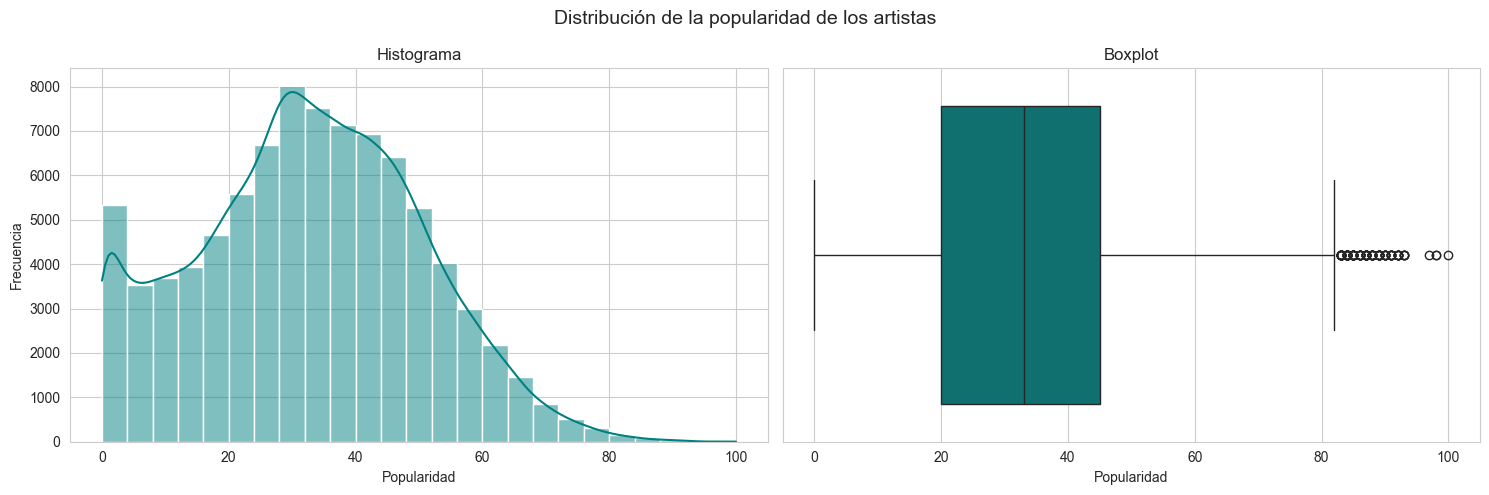

5322
6.099993122893886


In [381]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15,5))

fig.suptitle(
    'Distribución de la popularidad de los artistas',
    fontsize=14
)

sns.histplot(
    datos_artista['artist_popularity'],
    bins=25,
    color='teal',
    kde=True,
    ax=axes[0]
)

axes[0].set_xlabel('Popularidad')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Histograma')

sns.boxplot(
    x=datos_artista['artist_popularity'],
    color='teal',
    ax=axes[1]
)

axes[1].set_xlabel('Popularidad')
axes[1].set_title('Boxplot')

plt.tight_layout()

plt.show()

print((datos_artista['artist_popularity'] < 4).sum())
print((datos_artista['artist_popularity'] < 4).mean()*100)

La distribución de la popularidad de los artistas se concentra principalmente en valores intermedios. La media (32.55) y la mediana (33) presentan valores similares, lo que indica una distribución equilibrada alrededor de su centro.

El coeficiente de asimetría (skewness = 0.086) es muy cercano a cero, por lo que la distribución puede considerarse aproximadamente simétrica. Esto sugiere que no existe una concentración excesiva de artistas en alguno de los extremos de la escala de popularidad.

Además, el 50% de los artistas posee una popularidad comprendida entre 20 y 45 puntos. Por otro lado, los artistas con popularidades superiores a 80 son poco frecuentes y aparecen como valores atípicos en el boxplot.

En general, los resultados muestran que la mayoría de los artistas del conjunto de datos se concentra en niveles intermedios de popularidad, mientras que los artistas extremadamente populares representan una proporción reducida de la muestra.

## Seguidores de los artistas

In [382]:
import numpy as np

print(datos_artista['artist_followers'].describe(
    percentiles=[0.25,0.5,0.75,0.9,0.95,0.99]
))

print(datos_artista['artist_followers'].skew())

print(
    np.log1p(
        datos_artista['artist_followers']
    ).skew()
)

count    8.724600e+04
mean     1.690926e+05
std      1.397805e+06
min      0.000000e+00
25%      5.690000e+02
50%      4.574500e+03
75%      3.354800e+04
90%      1.900030e+05
95%      5.362260e+05
99%      2.976655e+06
max      1.109235e+08
Name: artist_followers, dtype: float64
32.191052022632775
0.008705707668820208


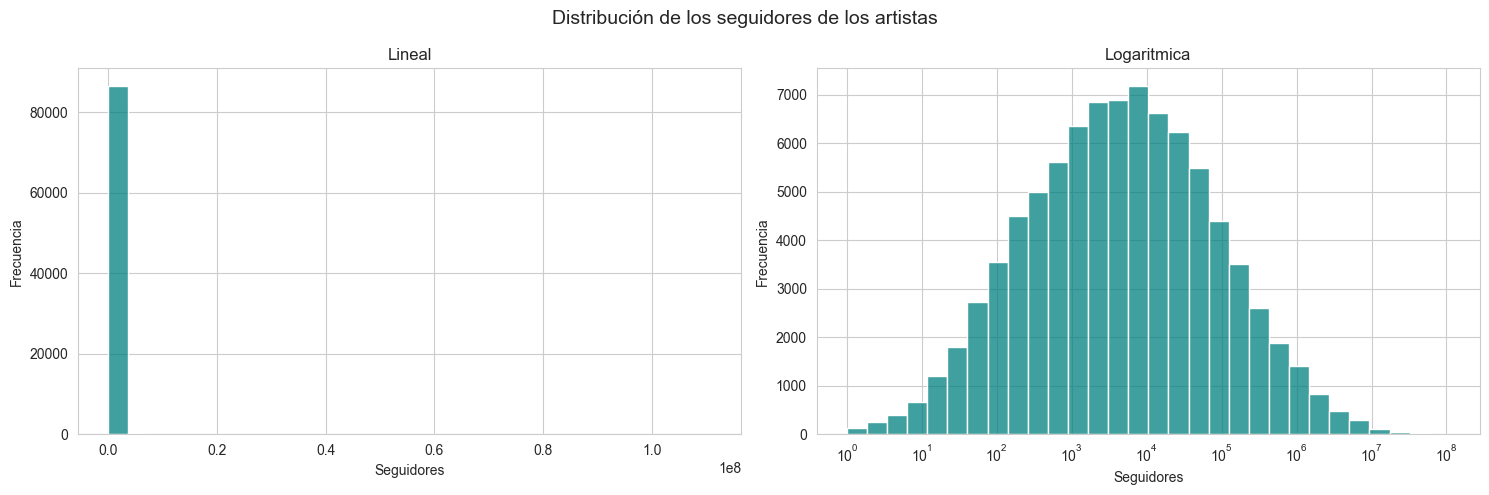

In [383]:
import numpy as np

followers_log = np.log1p(
    datos_artista['artist_followers']
)

fig, axes = plt.subplots(1, 2, figsize=(15,5))

fig.suptitle(
    'Distribución de los seguidores de los artistas',
    fontsize=14
)

sns.histplot(
    datos_artista['artist_followers'],
    bins=30,
    color='teal',
    ax=axes[0]
)

axes[0].set_xlabel('Seguidores')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Lineal')

sns.histplot(
    datos_artista['artist_followers'],
    bins=30,
    color='teal',
    log_scale=True,
    ax=axes[1]
)

axes[1].set_xlabel('Seguidores')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Logaritmica')

plt.tight_layout()

plt.show()

La distribución original del número de seguidores presenta una fuerte asimetría positiva, evidenciada por un coeficiente de asimetría (skewness) de 32.19. Esto indica que la mayoría de los artistas posee relativamente pocos seguidores, mientras que un pequeño grupo concentra cantidades extremadamente altas de seguidores.

Debido a esta diferencia de escalas, se utilizó una transformación logarítmica para facilitar la visualización e interpretación de los datos. En la escala logarítmica.

Tras aplicar la transformación logarítmica, el coeficiente de asimetría disminuye a 0.0087, un valor prácticamente nulo. Además, la distribución adquiere una forma aproximadamente simétrica.

En términos generales, la mayoría de los artistas se concentra en rangos intermedios de seguidores, mientras que los artistas con millones de seguidores representan una proporción reducida del conjunto de datos.

## Relación entre popularidad y seguidores

- ¿Los artistas con más seguidores tieden a ser más populares?

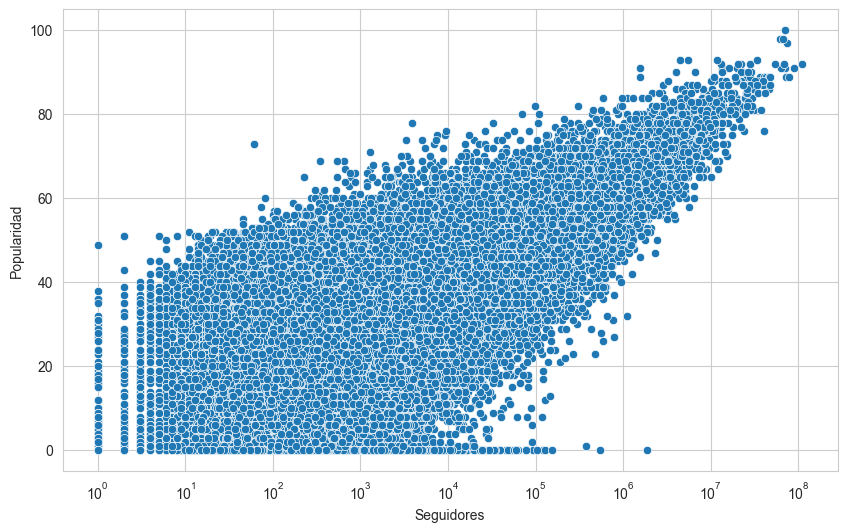

In [384]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=datos_artista,
    x='artist_followers',
    y='artist_popularity',
)

plt.xscale('log')

plt.xlabel('Seguidores')
plt.ylabel('Popularidad')

plt.show()

In [385]:
datos_artista[
    ['artist_followers', 'artist_popularity']
].corr(method='pearson')


,artist_followers,artist_popularity
artist_followers,1.000000,0.256737
artist_popularity,0.256737,1.000000


In [386]:
datos_artista[
    ['artist_followers', 'artist_popularity']
].corr(method='spearman')

,artist_followers,artist_popularity
artist_followers,1.000000,0.734809
artist_popularity,0.734809,1.000000


<Axes: xlabel='grupo_popularidad', ylabel='artist_followers'>

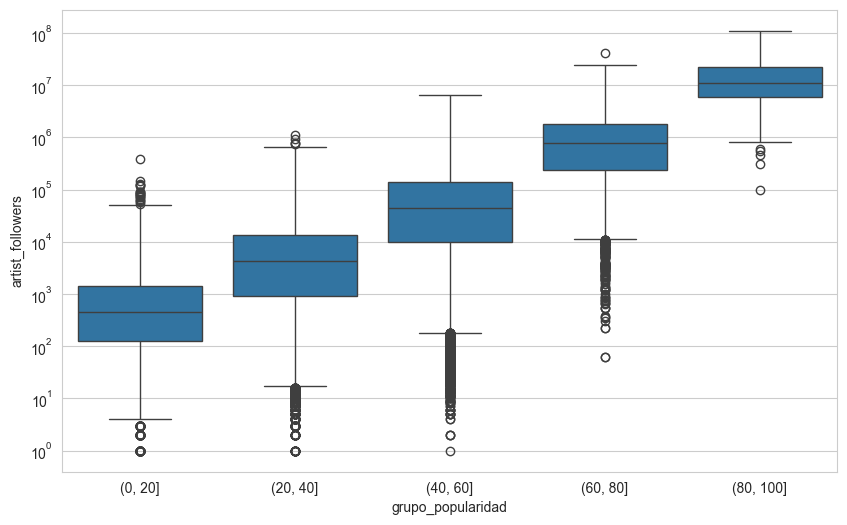

In [387]:
datos_artista['grupo_popularidad'] = pd.cut(
    datos_artista['artist_popularity'],
    bins=[0,20,40,60,80,100]
)

plt.figure(figsize=(10,6))

sns.boxplot(
    data=datos_artista,
    x='grupo_popularidad',
    log_scale=True,
    y=datos_artista['artist_followers']
)

La nube de puntos muestra una tendencia creciente entre ambas variables. En general, los artistas con una mayor cantidad de seguidores tienden a presentar mayores niveles de popularidad. Sin embargo, la relación observada no parece ser estrictamente lineal.

Esta observación se ve respaldada por los coeficientes de correlación obtenidos:

- Correlación de Pearson: 0.257
- Correlación de Spearman: 0.735

La correlación de Pearson indica una asociación lineal positiva relativamente débil, mientras que la correlación de Spearman muestra una asociación monótona positiva fuerte. Esto sugiere que, aunque el aumento de seguidores suele venir acompañado de un aumento en la popularidad, dicho incremento no ocurre de manera proporcional o lineal.

Adicionalmente, los diagramas de caja construidos para distintos grupos de popularidad muestran un incremento progresivo en la distribución del número de seguidores. Los grupos con mayor popularidad presentan, en general, una mayor cantidad de seguidores y un menor solapamiento con los grupos de menor popularidad.

En conjunto, estos resultados indican que existe una relación positiva importante entre el número de seguidores y la popularidad del artista. No obstante, dicha relación parece ser de naturaleza no lineal.

## Diversidad de géneros



In [388]:
import numpy as np

datos_artista['n_generos'] = datos_artista['artist_genres'].apply(len)

print(
    datos_artista['n_generos'].describe(
        percentiles=[0.5,0.75,0.9,0.95,0.99]
    )
)

count    87246.000000
mean         1.498957
std          3.447145
min          0.000000
50%          1.000000
75%          2.000000
90%          4.000000
95%          5.000000
99%          8.000000
max        270.000000
Name: n_generos, dtype: float64


Los estadisticos descriptivas muestran que la media es de 1.5 géneros por artista, mientras que el 75% de los artistas posee 2 géneros o menos. Asimismo, el 90% de los artistas tiene 4 géneros o menos y el 99% posee hasta 8 géneros asociados. Estos resultados sugieren que la mayoría de los artistas están clasificados dentro de pocos estilos musicales, lo que indica un alto grado de especialización.

In [389]:
valores_unicos = list(set(datos_artista['n_generos']))

valores_unicos.sort()

segundo_mas_grande = valores_unicos[-2]

print("Segundo numero más grande:", segundo_mas_grande)

datos_artista.loc[
    datos_artista['n_generos'].idxmax(),
    ['artist_uri','artist_genres']
]

Segundo numero más grande: 18


artist_uri                   spotify:artist:5kPedB70NoaucwCvU7awih
artist_genres    [abstract idm, accordion band, adoracao, alber...
Name: 7638, dtype: object

Durante la exploración se detectó la presencia de valores atípicos extremos. El artista con mayor cantidad de géneros asociados posee 270 géneros, mientras que el segundo valor más alto es únicamente 18. Debido a esta diferencia considerable, las visualizaciones fueron limitadas al percentil 99 con el fin de representar adecuadamente el comportamiento de la gran mayoría de los artistas sin que los valores extremos distorsionaran la interpretación.

## Visualización de la distribución

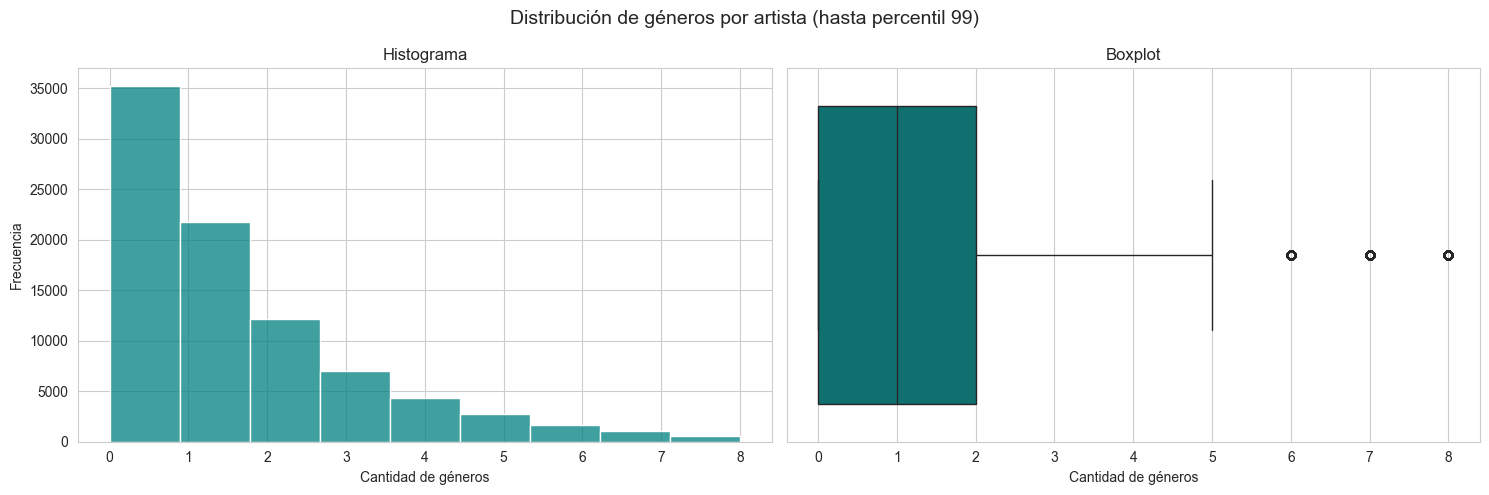

35200
40.34568920065103


In [390]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))

limite = datos_artista['n_generos'].quantile(0.99)

fig.suptitle(
    'Distribución de géneros por artista (hasta percentil 99)',
    fontsize=14
)

sns.histplot(
    datos_artista['n_generos'][
        datos_artista['n_generos'] <= limite
    ],
    bins=9,
    color='teal',
    ax=axes[0]
)

axes[0].set_xlabel('Cantidad de géneros')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Histograma')

sns.boxplot(
    x=datos_artista['n_generos'][
        datos_artista['n_generos'] <= limite
    ],
    color='teal',
    ax=axes[1]
)

axes[1].set_xlabel('Cantidad de géneros')
axes[1].set_title('Boxplot')

plt.tight_layout()

plt.show()

print((datos_artista['n_generos'] == 0).sum())
print((datos_artista['n_generos'] == 0).mean() * 100)

La distribución de la cantidad de géneros asociados a cada artista presenta una marcada asimetría positiva. La mayoría de los artistas se concentra en valores bajos, mientras que existe una pequeña proporción de artistas asociados a una gran cantidad de géneros.

El histograma confirma que la frecuencia disminuye rápidamente conforme aumenta la cantidad de géneros asociados, mientras que el boxplot evidencia que los artistas con 6 o más géneros continúan siendo observaciones poco frecuentes incluso después de excluir el 1% superior de los datos.

Adicionalmente, se observó que 35,200 artistas no poseen géneros asociados en la información obtenida, lo que representa aproximadamente el 40.35% del conjunto de datos. Esto podría constituir una limitación importante para análsis posteriores relacionados con la diversidad músical, ya que una porción significativa carecen de información respecto a los géneros.

En conjunto, estos resultados sugieren que la diversidad de géneros es relativamente baja para la mayoría de los artistas del conjunto de datos y que los artistas asociados a una gran variedad de géneros constituyen casos excepcionales.


## Relación entre popularidad y la cantidad de géneros del artista

<Axes: xlabel='n_generos', ylabel='artist_popularity'>

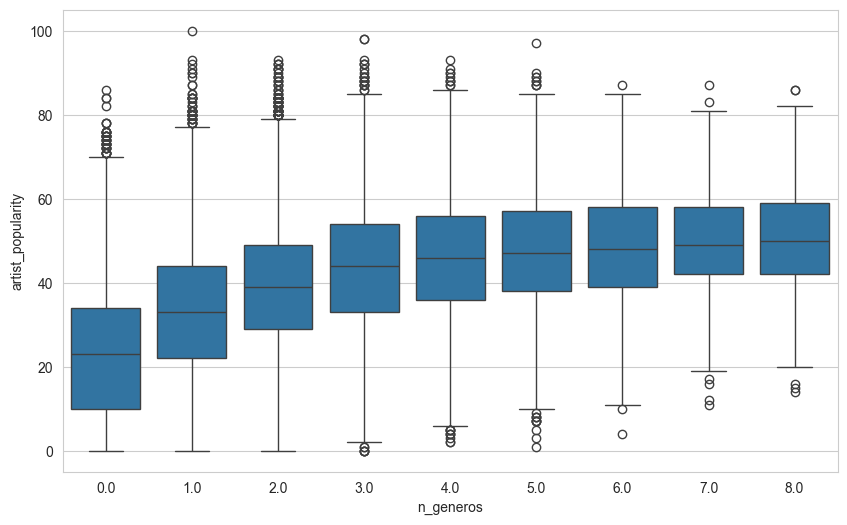

In [391]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=datos_artista['n_generos'][
        datos_artista['n_generos'] <= limite
    ],
    y = datos_artista['artist_popularity']
)

Aunque existe solapamiento entre los grupos, se observa una tendencia creciente en las medianas de popularidad. Conforme aumenta la cantidad de géneros asociados a un artista, la distribución de popularidad tiende a desplazarse hacia valores más altos.

Esto puede sugerir una posible relación positiva entre la diversidad de géneros y la popularidad del artista.

In [392]:
resumen = (
    datos_artista
    .groupby(datos_artista['n_generos'][datos_artista['n_generos'] <= limite])['artist_popularity']
    .agg(['count','mean','median'])
)

resumen

,count,mean,median
n_generos,,,
0.0,35200,23.213892,23.0
1.0,21748,32.818420,33.0
2.0,12147,39.187865,39.0
3.0,7008,43.396404,44.0
4.0,4281,45.952815,46.0
5.0,2726,47.061629,47.0
6.0,1704,48.575704,48.0
7.0,1044,49.581418,49.0
8.0,615,50.213008,50.0


Las estadísticas muestran una tendencia claramente creciente tanto en la media como en la mediana de popularidad.

Los artistas sin géneros asociados presentan una mediana de popularidad de 23 puntos. Esta mediana aumenta a 33 para artistas con un género, 39 para aquellos con dos géneros y 44 para quienes poseen tres géneros asociados.

A partir de cuatro géneros, el incremento continúa de manera más gradual, alcanzando una mediana cercana a 50 puntos para los artistas con ocho géneros.

<Axes: xlabel='n_generos', ylabel='artist_popularity'>

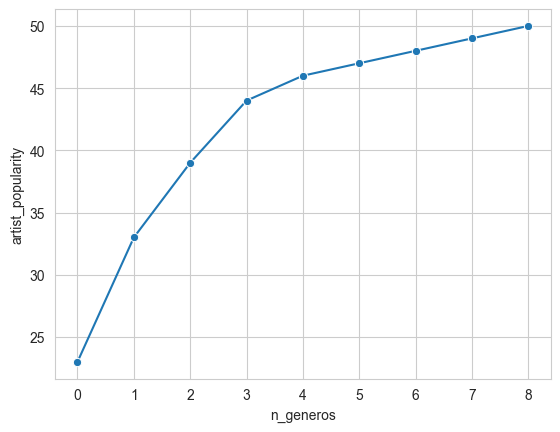

In [400]:
datos_filtrados = datos_artista[datos_artista['n_generos'] <= limite]

popularidad_por_generos = (
    datos_filtrados
    .groupby('n_generos')['artist_popularity']
    .median()
    .reset_index()
)

sns.lineplot(
    data=popularidad_por_generos,
    x='n_generos',
    y='artist_popularity',
    marker='o'
)

La popularidad aumenta de forma más pronunciada entre los artistas con cero, uno, dos y tres géneros asociados. Posteriormente, el crecimiento continúa, aunque de forma más gradual.

La ausencia de descensos significativos en las medianas refuerza la hipótesis de que existe una relación positiva entre ambas variables.

In [ ]:
datos_filtrados[
    ['n_generos', 'artist_popularity']
].corr(method='spearman')

,n_generos,artist_popularity
n_generos,1.000000,0.499417
artist_popularity,0.499417,1.000000


In [399]:
datos_filtrados[
    ['n_generos', 'artist_popularity']
].corr(method='pearson')

,n_generos,artist_popularity
n_generos,1.000000,0.465994
artist_popularity,0.465994,1.000000


La correlación de Pearson obtuvo un valor de 0.466, indicando una relación lineal positiva de magnitud moderada entre la cantidad de géneros y la popularidad.

Por su parte, la correlación de Spearman obtuvo un valor de 0.499, lo que indica una relación monótona positiva también de intensidad moderada.

La similitud entre ambos coeficientes sugiere que la relación observada es relativamente estable y que el aumento en la cantidad de géneros suele estar acompañado de un aumento en la popularidad del artista.

<Axes: xlabel='tiene_generos', ylabel='artist_popularity'>

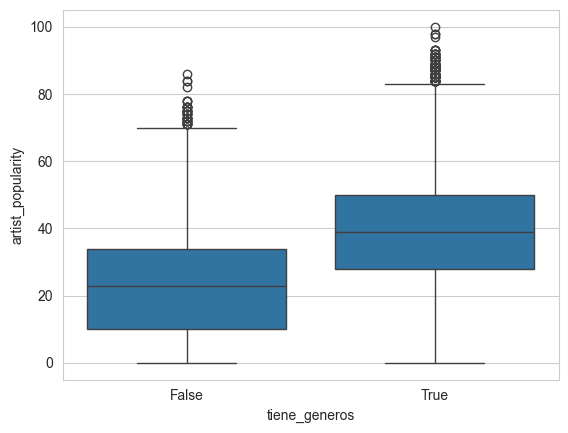

In [395]:
datos_artista['tiene_generos'] = (
    datos_artista['n_generos'] > 0
)

sns.boxplot(
    data=datos_artista,
    x='tiene_generos',
    y='artist_popularity'
)

Los distintos análisis realizados muestran evidencia consistente de una relación positiva entre la cantidad de géneros asociados a un artista y su popularidad.

No obstante, la magnitud moderada de las correlaciones y el solapamiento observado entre los grupos sugieren que la cantidad de géneros no es el único factor que influye en la popularidad. Es importante recordar que correlación no significa causalidad